# Iteración 04 - Optimización ampliada de SVM con GridSearchCV

Este notebook toma como punto de partida que el mejor modelo de la iteración anterior fue SVM. La búsqueda se concentra en `LinearSVC`, ampliando la variación de hiperparámetros y manteniendo las buenas prácticas metodológicas:

- separación independiente en `train`, `val` y `test`;
- target numérico controlado, donde el menor código corresponde a `Nivel 1: Insuficiente`;
- preprocesamiento dentro de un `Pipeline`, para que imputadores, codificadores y escaladores se ajusten solo con los datos permitidos en cada etapa;
- `GridSearchCV` con `StratifiedKFold` de 5 folds sobre `train`;
- selección con F1 macro en validación;
- evaluación final una sola vez sobre `test`.


## 1. Configuración inicial

In [1]:
# ============================================================
# 1. Configuración inicial
# ============================================================

import os
import re
import json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

SEED = 42
np.random.seed(SEED)

BASE_DIR = "/content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output"
DATASET_PATH = os.path.join(BASE_DIR, "DataSetInicial.csv")
COLUMNAS_ELIMINAR_PATH = os.path.join(BASE_DIR, "Columas a Eliminar.csv")

TARGET_COL = "target"

# En el dataset completo, déjalo en False. Para pruebas rápidas, cambia a True.
MODO_DESARROLLO = False
N_FILAS_DESARROLLO = 100_000

# Configuración de la partición train/val/test.
TEST_SIZE = 0.20
VAL_SIZE = 0.20
K_FOLDS = 5
METRICA_PRINCIPAL = "f1_macro"

print("Ruta dataset:", DATASET_PATH)
print("Ruta columnas a eliminar:", COLUMNAS_ELIMINAR_PATH)
print("K folds:", K_FOLDS)


Ruta dataset: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/DataSetInicial.csv
Ruta columnas a eliminar: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/Columas a Eliminar.csv
K folds: 5


In [2]:
# ============================================================
# 1.1 Métricas multiclase
# ============================================================

# La variable objetivo es multiclase. Por eso se usa F1 macro y nunca scoring="f1",
# porque "f1" es binario por defecto y puede generar errores con pos_label.

def calcular_metricas_multiclase(y_true, y_pred, prefijo=""):
    p = f"{prefijo}_" if prefijo else ""
    return {
        f"{p}accuracy": accuracy_score(y_true, y_pred),
        f"{p}f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        f"{p}f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

print("Métrica principal:", METRICA_PRINCIPAL)


Métrica principal: f1_macro


## 2. Montar Google Drive

In [3]:
# ============================================================
# 2. Montar Google Drive
# ============================================================

from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## 3. Carga del dataset y archivo de columnas a eliminar

In [4]:
# ============================================================
# 3. Carga del dataset y columnas a eliminar
# ============================================================

def limpiar_nombre_columnas(df):
    """
    Normaliza nombres de columnas:
    - elimina espacios extremos,
    - elimina caracteres BOM,
    - convierte a minúscula.
    """
    df = df.copy()
    df.columns = (
        df.columns
        .astype(str)
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
        .str.lower()
    )
    return df


if MODO_DESARROLLO:
    df = pd.read_csv(
        DATASET_PATH,
        encoding="utf-8-sig",
        low_memory=False,
        nrows=N_FILAS_DESARROLLO
    )
else:
    df = pd.read_csv(
        DATASET_PATH,
        encoding="utf-8-sig",
        low_memory=False
    )

df = limpiar_nombre_columnas(df)

columnas_eliminar_df = pd.read_csv(
    COLUMNAS_ELIMINAR_PATH,
    encoding="utf-8-sig",
    low_memory=False
)

columnas_eliminar_df = limpiar_nombre_columnas(columnas_eliminar_df)

print("Shape dataset inicial:", df.shape)
display(df.head())

print("\nArchivo de columnas a eliminar:")
display(columnas_eliminar_df)

Shape dataset inicial: (566241, 33)


,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_depto_ubicacion,cole_genero,cole_jornada,...,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_personashogar,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,target
0,20224,TI,SB11202240536228,URBANO,N,A,TÉCNICO/ACADÉMICO,CAQUETA,MIXTO,UNICA,...,Cuatro,Primaria incompleta,Primaria incompleta,Estrato 2,5 a 6,No,No,No,Si,Nivel 2: Mínimo
1,20224,TI,SB11202240549969,URBANO,N,A,TÉCNICO/ACADÉMICO,QUINDIO,MIXTO,MAÑANA,...,Dos,Educación profesional completa,No Aplica,Estrato 2,3 a 4,No,No,Si,Si,Nivel 2: Mínimo
2,20211,TI,SB11202110001547,RURAL,S,B,ACADÉMICO,CUNDINAMARCA,MIXTO,COMPLETA,...,Tres,Educación profesional completa,Postgrado,Estrato 4,3 a 4,Si,Si,Si,Si,Nivel 3: Satisfactorio
3,20211,CR,SB11202110021004,URBANO,NaN,A,ACADÉMICO,CUNDINAMARCA,MIXTO,MAÑANA,...,Tres,Educación profesional completa,Educación profesional completa,Estrato 5,1 a 2,Si,Si,Si,Si,Nivel 3: Satisfactorio
4,20224,TI,SB11202240101947,RURAL,NaN,A,NO APLICA,ANTIOQUIA,MIXTO,COMPLETA,...,Dos,Primaria incompleta,Primaria incompleta,Estrato 2,3 a 4,No,No,No,No,Nivel 3: Satisfactorio



Archivo de columnas a eliminar:


,columna_a_eliminar
0,cole_area_ubicacion
1,estu_mcpio_presentacion
2,estu_nacionalidad
3,estu_depto_presentacion
4,fami_tieneautomovil
5,cole_depto_ubicacion
6,estu_depto_reside
7,fami_tienelavadora
8,estu_mcpio_reside
9,estu_estudiante


## 4. Validaciones iniciales

In [5]:
# ============================================================
# 4. Validaciones iniciales
# ============================================================

if TARGET_COL not in df.columns:
    raise ValueError(f"No existe la variable objetivo '{TARGET_COL}' en el dataset.")

if columnas_eliminar_df.shape[1] == 1:
    col_lista_eliminar = columnas_eliminar_df.columns[0]
else:
    col_lista_eliminar = "columna_a_eliminar"
    if col_lista_eliminar not in columnas_eliminar_df.columns:
        raise ValueError(
            "El archivo de columnas a eliminar debe tener una columna llamada "
            "'columna_a_eliminar' o una única columna con el listado."
        )

columnas_a_eliminar = (
    columnas_eliminar_df[col_lista_eliminar]
    .dropna()
    .astype(str)
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
    .str.lower()
    .tolist()
)

columnas_a_eliminar = sorted(set(columnas_a_eliminar + ["periodo"]))

print("Variable objetivo:", TARGET_COL)
print("Cantidad de columnas solicitadas para eliminar:", len(columnas_a_eliminar))
print(columnas_a_eliminar)

Variable objetivo: target
Cantidad de columnas solicitadas para eliminar: 15
['cole_area_ubicacion', 'cole_depto_ubicacion', 'cole_sede_principal', 'estu_depto_presentacion', 'estu_depto_reside', 'estu_estadoinvestigacion', 'estu_estudiante', 'estu_mcpio_presentacion', 'estu_mcpio_reside', 'estu_nacionalidad', 'estu_pais_reside', 'estu_privado_libertad', 'fami_tieneautomovil', 'fami_tienelavadora', 'periodo']


## 5. Eliminación de columnas y control de duplicados

In [6]:
# ============================================================
# 5. Eliminación de columnas y duplicados por estu_consecutivo
# ============================================================

columnas_existentes_a_eliminar = [col for col in columnas_a_eliminar if col in df.columns]
columnas_no_encontradas = [col for col in columnas_a_eliminar if col not in df.columns]

df_model = df.drop(columns=columnas_existentes_a_eliminar).copy()

print("Columnas eliminadas efectivamente:", len(columnas_existentes_a_eliminar))
print(columnas_existentes_a_eliminar)

if columnas_no_encontradas:
    print("\nColumnas solicitadas pero no encontradas en el dataset:")
    print(columnas_no_encontradas)

if "estu_consecutivo" in df_model.columns:
    registros_antes = len(df_model)
    duplicados = df_model.duplicated(subset=["estu_consecutivo"], keep=False).sum()

    print(f"\nRegistros involucrados en duplicados por estu_consecutivo: {duplicados:,}")

    df_model = (
        df_model
        .drop_duplicates(subset=["estu_consecutivo"], keep="first")
        .reset_index(drop=True)
    )

    registros_despues = len(df_model)
    print(f"Registros antes: {registros_antes:,}")
    print(f"Registros después de eliminar duplicados: {registros_despues:,}")
    print(f"Registros eliminados: {registros_antes - registros_despues:,}")

print("\nShape después de eliminación de columnas y duplicados:", df_model.shape)
display(df_model.head())

Columnas eliminadas efectivamente: 15
['cole_area_ubicacion', 'cole_depto_ubicacion', 'cole_sede_principal', 'estu_depto_presentacion', 'estu_depto_reside', 'estu_estadoinvestigacion', 'estu_estudiante', 'estu_mcpio_presentacion', 'estu_mcpio_reside', 'estu_nacionalidad', 'estu_pais_reside', 'estu_privado_libertad', 'fami_tieneautomovil', 'fami_tienelavadora', 'periodo']

Registros involucrados en duplicados por estu_consecutivo: 0
Registros antes: 566,241
Registros después de eliminar duplicados: 566,241
Registros eliminados: 0

Shape después de eliminación de columnas y duplicados: (566241, 18)


,estu_tipodocumento,estu_consecutivo,cole_bilingue,cole_calendario,cole_caracter,cole_genero,cole_jornada,cole_mcpio_ubicacion,cole_naturaleza,estu_genero,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_personashogar,fami_tienecomputador,fami_tieneinternet,target
0,TI,SB11202240536228,N,A,TÉCNICO/ACADÉMICO,MIXTO,UNICA,EL DONCELLO,OFICIAL,F,Cuatro,Primaria incompleta,Primaria incompleta,Estrato 2,5 a 6,No,No,Nivel 2: Mínimo
1,TI,SB11202240549969,N,A,TÉCNICO/ACADÉMICO,MIXTO,MAÑANA,ARMENIA,OFICIAL,F,Dos,Educación profesional completa,No Aplica,Estrato 2,3 a 4,No,Si,Nivel 2: Mínimo
2,TI,SB11202110001547,S,B,ACADÉMICO,MIXTO,COMPLETA,SOPÓ,NO OFICIAL,M,Tres,Educación profesional completa,Postgrado,Estrato 4,3 a 4,Si,Si,Nivel 3: Satisfactorio
3,CR,SB11202110021004,NaN,A,ACADÉMICO,MIXTO,MAÑANA,TENJO,NO OFICIAL,M,Tres,Educación profesional completa,Educación profesional completa,Estrato 5,1 a 2,Si,Si,Nivel 3: Satisfactorio
4,TI,SB11202240101947,NaN,A,NO APLICA,MIXTO,COMPLETA,ANDES,OFICIAL,M,Dos,Primaria incompleta,Primaria incompleta,Estrato 2,3 a 4,No,No,Nivel 3: Satisfactorio


## 6. Separación de variables y codificación del target

In [7]:
# ============================================================
# 6. Separación X/y original
# ============================================================

# Se eliminan registros sin target, porque no pueden usarse en entrenamiento supervisado.
df_model = df_model.dropna(subset=[TARGET_COL]).reset_index(drop=True)

id_cols_no_modelar = ["estu_consecutivo"]
id_cols_no_modelar = [col for col in id_cols_no_modelar if col in df_model.columns]

X = df_model.drop(columns=[TARGET_COL] + id_cols_no_modelar).copy()
y_texto = (
    df_model[TARGET_COL]
    .astype(str)
    .str.strip()
    .copy()
)

y_texto.name = TARGET_COL

print("Shape X:", X.shape)
print("Shape y_texto:", y_texto.shape)

print("\nDistribución original del target textual:")
display(y_texto.value_counts(dropna=False).to_frame("frecuencia"))
display((y_texto.value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("porcentaje"))


Shape X: (566241, 16)
Shape y_texto: (566241,)

Distribución original del target textual:


,frecuencia
target,
Nivel 2: Mínimo,268741
Nivel 3: Satisfactorio,170346
Nivel 1: Insuficiente,104523
Nivel 4: Avanzado,22631


,porcentaje
target,
Nivel 2: Mínimo,47.46
Nivel 3: Satisfactorio,30.08
Nivel 1: Insuficiente,18.46
Nivel 4: Avanzado,4.00


In [8]:
# ============================================================
# 6.1 Codificación numérica del target con LabelEncoder
# ============================================================

# Algunos algoritmos trabajan de forma más estable con targets numéricos.
# En este proyecto, las clases tienen un número explícito en el texto:
# "Nivel 1", "Nivel 2", "Nivel 3", "Nivel 4".
# Por decisión metodológica, el target del modelo usará esos números: 1, 2, 3 y 4.

PATRON_NIVEL_TARGET = re.compile(r"nivel\s*(\d+)", flags=re.IGNORECASE)


def extraer_numero_nivel(etiqueta):
    """
    Extrae el número de nivel desde una etiqueta tipo:
    'Nivel 1: Insuficiente'.
    """
    if pd.isna(etiqueta):
        return np.nan

    etiqueta_str = str(etiqueta).strip()
    match = PATRON_NIVEL_TARGET.search(etiqueta_str)

    if match is None:
        return np.nan

    return int(match.group(1))


# Identificación de clases y ordenamiento por el número real del nivel.
etiquetas_target_unicas = pd.Series(y_texto.unique(), name="etiqueta_original")

mapeo_target = pd.DataFrame({
    "etiqueta_original": etiquetas_target_unicas
})
mapeo_target["nivel_extraido"] = mapeo_target["etiqueta_original"].apply(extraer_numero_nivel)

if mapeo_target["nivel_extraido"].isna().any():
    display(mapeo_target[mapeo_target["nivel_extraido"].isna()])
    raise ValueError(
        "Existen etiquetas del target en las que no fue posible extraer el número de nivel. "
        "Revisa los valores de la variable objetivo antes de continuar."
    )

if mapeo_target["nivel_extraido"].duplicated().any():
    display(mapeo_target.sort_values("nivel_extraido"))
    raise ValueError(
        "Hay más de una etiqueta asociada al mismo número de nivel. "
        "Esto puede indicar inconsistencias en la variable objetivo."
    )

mapeo_target = mapeo_target.sort_values("nivel_extraido").reset_index(drop=True)

# LabelEncoder se inicializa con las clases en el orden metodológico correcto.
# El código propio de LabelEncoder es 0, 1, 2, 3, pero se conserva solo como
# referencia técnica. El target final del modelo usa el número real del nivel: 1, 2, 3 y 4.
target_label_encoder = LabelEncoder()
target_label_encoder.classes_ = mapeo_target["etiqueta_original"].to_numpy(dtype=object)

mapeo_target["codigo_labelencoder_0_based"] = target_label_encoder.transform(
    mapeo_target["etiqueta_original"]
)
mapeo_target["codigo_target_modelo"] = mapeo_target["nivel_extraido"].astype(int)

TARGET_LABELS_ORIGINALES = mapeo_target["etiqueta_original"].tolist()
TARGET_LABELS_CODIFICADOS = mapeo_target["codigo_target_modelo"].tolist()
TARGET_CODIGO_A_ETIQUETA = dict(zip(
    mapeo_target["codigo_target_modelo"],
    mapeo_target["etiqueta_original"]
))
TARGET_ETIQUETA_A_CODIGO = dict(zip(
    mapeo_target["etiqueta_original"],
    mapeo_target["codigo_target_modelo"]
))
N_CLASES_TARGET = len(TARGET_LABELS_CODIFICADOS)

# Transformación final del target: se toma el número explícito de cada nivel.
y = y_texto.map(TARGET_ETIQUETA_A_CODIGO)

if y.isna().any():
    raise ValueError("No fue posible codificar todos los valores de la variable objetivo.")

y = pd.Series(
    y.astype(int),
    index=y_texto.index,
    name=f"{TARGET_COL}_codificado"
)

# Validaciones de coherencia.
assert y.min() == min(TARGET_LABELS_CODIFICADOS), (
    "El menor código del target no coincide con el menor código definido en el mapeo."
)
assert "nivel 1" in TARGET_CODIGO_A_ETIQUETA[min(TARGET_LABELS_CODIFICADOS)].lower(), (
    "El menor código del target no quedó asociado a Nivel 1."
)
assert np.array_equal(
    mapeo_target["codigo_labelencoder_0_based"].to_numpy(),
    np.arange(len(mapeo_target))
), "LabelEncoder no quedó alineado con el orden metodológico del target."


def decodificar_target(y_codificado):
    """
    Convierte códigos numéricos 1..K nuevamente a etiquetas textuales originales.
    """
    y_array = np.asarray(y_codificado).astype(int)

    codigos_no_validos = sorted(set(y_array) - set(TARGET_LABELS_CODIFICADOS))
    if codigos_no_validos:
        raise ValueError(f"Códigos de target no reconocidos: {codigos_no_validos}")

    return pd.Series(y_array).map(TARGET_CODIGO_A_ETIQUETA).to_numpy()


print("Mapeo final del target usado por todos los modelos:")
display(mapeo_target[[
    "codigo_target_modelo",
    "etiqueta_original",
    "nivel_extraido",
    "codigo_labelencoder_0_based"
]])

print("\nDistribución del target codificado:")
distribucion_y = (
    y.value_counts()
    .sort_index()
    .rename("frecuencia")
    .to_frame()
    .rename_axis("codigo_target_modelo")
    .reset_index()
)
distribucion_y["etiqueta_original"] = distribucion_y["codigo_target_modelo"].map(TARGET_CODIGO_A_ETIQUETA)
display(distribucion_y[["codigo_target_modelo", "etiqueta_original", "frecuencia"]])

print("\nValidación de correspondencia código ↔ etiqueta:")
validacion_mapeo = pd.DataFrame({
    "codigo_target_modelo": TARGET_LABELS_CODIFICADOS,
    "etiqueta_decodificada": decodificar_target(TARGET_LABELS_CODIFICADOS)
})
display(validacion_mapeo)

print("Codificación validada: el menor código corresponde a Nivel 1 y el target es numérico.")


Mapeo final del target usado por todos los modelos:


,codigo_target_modelo,etiqueta_original,nivel_extraido,codigo_labelencoder_0_based
0,1,Nivel 1: Insuficiente,1,0
1,2,Nivel 2: Mínimo,2,1
2,3,Nivel 3: Satisfactorio,3,2
3,4,Nivel 4: Avanzado,4,3



Distribución del target codificado:


,codigo_target_modelo,etiqueta_original,frecuencia
0,1,Nivel 1: Insuficiente,104523
1,2,Nivel 2: Mínimo,268741
2,3,Nivel 3: Satisfactorio,170346
3,4,Nivel 4: Avanzado,22631



Validación de correspondencia código ↔ etiqueta:


,codigo_target_modelo,etiqueta_decodificada
0,1,Nivel 1: Insuficiente
1,2,Nivel 2: Mínimo
2,3,Nivel 3: Satisfactorio
3,4,Nivel 4: Avanzado


Codificación validada: el menor código corresponde a Nivel 1 y el target es numérico.


## 7. Revisión preventiva de leakage

In [9]:
# ============================================================
# 7. Revisión preventiva de leakage
# ============================================================

assert TARGET_COL not in X.columns, "La variable objetivo no debe estar dentro de X."

patrones_posible_leakage = [
    "target",
    "nivel",
    "desempeno",
    "desempeño",
    "puntaje",
    "punt_",
    "score",
    "resultado",
    "clasificacion",
    "clasificación",
    "label",
    "etiqueta"
]

columnas_sospechosas_leakage = sorted([
    col for col in X.columns
    if any(patron in col.lower() for patron in patrones_posible_leakage)
])

print("Columnas en X:", X.shape[1])
print("Columnas sospechosas de posible leakage:", len(columnas_sospechosas_leakage))

if columnas_sospechosas_leakage:
    display(pd.DataFrame({"columna_sospechosa": columnas_sospechosas_leakage}))
    print(
        "Revisa estas columnas. Si alguna fue construida a partir del target o de información "
        "que no estaría disponible al momento de predecir, debe eliminarse antes del split."
    )
else:
    print("No se detectaron columnas sospechosas por nombre.")

# Si después de la revisión metodológica confirmas columnas con leakage,
# inclúyelas en esta lista para retirarlas antes de dividir los datos.
COLUMNAS_LEAKAGE_CONFIRMADAS = []
COLUMNAS_LEAKAGE_CONFIRMADAS = [col for col in COLUMNAS_LEAKAGE_CONFIRMADAS if col in X.columns]

if COLUMNAS_LEAKAGE_CONFIRMADAS:
    X = X.drop(columns=COLUMNAS_LEAKAGE_CONFIRMADAS).copy()
    print("Columnas eliminadas por leakage confirmado:", COLUMNAS_LEAKAGE_CONFIRMADAS)
    print("Nuevo shape de X:", X.shape)
else:
    print("No se eliminaron columnas adicionales por leakage confirmado.")


Columnas en X: 16
Columnas sospechosas de posible leakage: 0
No se detectaron columnas sospechosas por nombre.
No se eliminaron columnas adicionales por leakage confirmado.


## 8. División train/validación/test

In [10]:
# ============================================================
# 8. Train/validation/test split
# ============================================================

min_clase = y.value_counts().min()
if min_clase < K_FOLDS:
    raise ValueError(
        f"La clase minoritaria tiene {min_clase} registros. "
        f"No es metodológicamente seguro ejecutar StratifiedKFold con {K_FOLDS} folds."
    )

stratify_y = y

# 1) Reserva final de test.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=stratify_y
)

# 2) Separación de validación desde el remanente.
val_size_relativo = VAL_SIZE / (1 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=val_size_relativo,
    random_state=SEED,
    stratify=y_train_val
)

# Validación explícita: todos los splits conservan la misma codificación numérica del target.
for nombre_split, y_split in {
    "train": y_train,
    "val": y_val,
    "test": y_test,
    "train_val": y_train_val
}.items():
    codigos_presentes = sorted(pd.Series(y_split).unique().tolist())
    codigos_no_validos = sorted(set(codigos_presentes) - set(TARGET_LABELS_CODIFICADOS))

    if codigos_no_validos:
        raise ValueError(
            f"El split {nombre_split} contiene códigos de target no reconocidos: {codigos_no_validos}"
        )

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

resumen_splits = pd.DataFrame({
    "dataset": ["train", "val", "test"],
    "registros": [len(X_train), len(X_val), len(X_test)],
    "porcentaje": [
        len(X_train) / len(X),
        len(X_val) / len(X),
        len(X_test) / len(X)
    ]
})
resumen_splits["porcentaje"] = (resumen_splits["porcentaje"] * 100).round(2)
display(resumen_splits)

print("\nDistribución porcentual del target codificado por split:")
dist_target_splits = pd.concat([
    (y_train.value_counts(normalize=True).sort_index() * 100).rename("train"),
    (y_val.value_counts(normalize=True).sort_index() * 100).rename("val"),
    (y_test.value_counts(normalize=True).sort_index() * 100).rename("test")
], axis=1).fillna(0).round(2)

dist_target_splits = (
    dist_target_splits
    .rename_axis("codigo_target_modelo")
    .reset_index()
)
dist_target_splits["etiqueta_original"] = dist_target_splits["codigo_target_modelo"].map(TARGET_CODIGO_A_ETIQUETA)
dist_target_splits = dist_target_splits[["codigo_target_modelo", "etiqueta_original", "train", "val", "test"]]
display(dist_target_splits)

print("\nValidación de codificación en los tres splits:")
for codigo in TARGET_LABELS_CODIFICADOS:
    print(f"{codigo} -> {TARGET_CODIGO_A_ETIQUETA[codigo]}")


X_train: (339744, 16)
X_val: (113248, 16)
X_test: (113249, 16)
y_train: (339744,)
y_val: (113248,)
y_test: (113249,)


,dataset,registros,porcentaje
0,train,339744,60.0
1,val,113248,20.0
2,test,113249,20.0



Distribución porcentual del target codificado por split:


,codigo_target_modelo,etiqueta_original,train,val,test
0,1,Nivel 1: Insuficiente,18.46,18.46,18.46
1,2,Nivel 2: Mínimo,47.46,47.46,47.46
2,3,Nivel 3: Satisfactorio,30.08,30.08,30.08
3,4,Nivel 4: Avanzado,4.00,4.00,4.00



Validación de codificación en los tres splits:
1 -> Nivel 1: Insuficiente
2 -> Nivel 2: Mínimo
3 -> Nivel 3: Satisfactorio
4 -> Nivel 4: Avanzado


## 9. Transformadores personalizados

In [11]:
# ============================================================
# 9. Transformadores personalizados
# ============================================================

class CrearMayorEdad(BaseEstimator, TransformerMixin):
    """
    Crea la columna 'Mayor edad' a partir de 'estu_tipodocumento':
    - CC -> mayor de edad
    - TI -> Menor de edad
    - Otro valor -> No definido
    Luego elimina 'estu_tipodocumento'.
    """

    def __init__(self, columna_documento="estu_tipodocumento", nueva_columna="Mayor edad"):
        self.columna_documento = columna_documento
        self.nueva_columna = nueva_columna

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        if self.columna_documento in X.columns:
            doc = (
                X[self.columna_documento]
                .astype("object")
                .fillna("NO DEFINIDO")
                .astype(str)
                .str.strip()
                .str.upper()
            )

            X[self.nueva_columna] = np.select(
                [doc.eq("CC"), doc.eq("TI")],
                ["mayor de edad", "Menor de edad"],
                default="No definido"
            )

            X = X.drop(columns=[self.columna_documento])

        return X


class AgruparCategorias(BaseEstimator, TransformerMixin):
    """
    Agrupa categorías específicas según reglas de negocio.
    """

    def __init__(self):
        self.mapa_educacion = {
            "Secundaria (Bachillerato) completa": "Secundaria",
            "Primaria incompleta": "Ninguna",
            "Secundaria (Bachillerato) incompleta": "Primaria",
            "Educación profesional completa": "Profesional",
            "Primaria completa": "Primaria",
            "No sabe": "Ninguna",
            "Técnica o tecnológica completa": "Tecnico",
            "Ninguno": "Ninguna",
            "Postgrado": "Postgrado",
            "Técnica o tecnológica incompleta": "Secundaria",
            "Educación profesional incompleta": "Secundaria",
            "No Aplica": "Ninguna"
        }

        self.mapa_municipio = {
            "BOGOTÁ D.C.": "Principal",
            "MEDELLÍN": "Principal",
            "CALI": "Principal",
            "BARRANQUILLA": "Intermedia",
            "CARTAGENA DE INDIAS": "Intermedia",
            "CÚCUTA": "Intermedia",
            "SOACHA": "Intermedia",
            "SOLEDAD": "Pequeña",
            "IBAGUÉ": "Pequeña",
            "SANTA MARTA": "Pequeña",
            "BUCARAMANGA": "Pequeña",
            "VILLAVICENCIO": "Pequeña"
        }

    def fit(self, X, y=None):
        return self

    @staticmethod
    def _mapear_serie(serie, mapa, default_original=True, valor_nulo=None, default_no_mapeado=None):
        s = serie.copy()

        if valor_nulo is not None:
            s = s.astype("object").fillna(valor_nulo)

        s_str = s.astype(str).str.strip()
        resultado = s_str.map(mapa)

        if default_no_mapeado is not None:
            resultado = resultado.fillna(default_no_mapeado)
        elif default_original:
            resultado = resultado.fillna(s_str)

        return resultado

    def transform(self, X):
        X = X.copy()

        for col in ["fami_educacionpadre", "fami_educacionmadre"]:
            if col in X.columns:
                X[col] = self._mapear_serie(
                    X[col],
                    self.mapa_educacion,
                    valor_nulo="Ninguna",
                    default_original=True
                )

        if "cole_mcpio_ubicacion" in X.columns:
            X["cole_mcpio_ubicacion"] = self._mapear_serie(
                X["cole_mcpio_ubicacion"],
                self.mapa_municipio,
                valor_nulo="Otra",
                default_original=False,
                default_no_mapeado="Otra"
            )

        return X

## 10. Definición de columnas para el preprocesamiento

In [12]:
# ============================================================
# 10. Definición de columnas para el preprocesamiento
# ============================================================

ordinal_cols = [
    "fami_estratovivienda",
    "fami_educacionmadre",
    "fami_educacionpadre",
    "fami_cuartoshogar",
    "fami_personashogar"
]

ordinal_cols = [col for col in ordinal_cols if col in X_train.columns]

categorical_cols_originales = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

nominal_cols = [
    col for col in categorical_cols_originales
    if col not in ordinal_cols and col != "estu_tipodocumento"
]

if "estu_tipodocumento" in X_train.columns:
    nominal_cols = nominal_cols + ["Mayor edad"]

nominal_cols = list(dict.fromkeys(nominal_cols))

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [
    col for col in numeric_cols
    if col not in ordinal_cols and col != "estu_tipodocumento"
]

print("Columnas ordinales:", ordinal_cols)
print("Columnas nominales:", nominal_cols)
print("Columnas numéricas:", numeric_cols)


Columnas ordinales: ['fami_estratovivienda', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_cuartoshogar', 'fami_personashogar']
Columnas nominales: ['cole_bilingue', 'cole_calendario', 'cole_caracter', 'cole_genero', 'cole_jornada', 'cole_mcpio_ubicacion', 'cole_naturaleza', 'estu_genero', 'fami_tienecomputador', 'fami_tieneinternet', 'Mayor edad']
Columnas numéricas: []


## 11. Pipeline de preprocesamiento

In [13]:
# ============================================================
# 11. Pipeline de preprocesamiento
# ============================================================

categorias_ordinales = []

for col in ordinal_cols:
    if col == "fami_estratovivienda":
        categorias_ordinales.append([
            "Sin Estrato",
            "Estrato 1",
            "Estrato 2",
            "Estrato 3",
            "Estrato 4",
            "Estrato 5",
            "Estrato 6"
        ])

    elif col in ["fami_educacionmadre", "fami_educacionpadre"]:
        categorias_ordinales.append([
            "Ninguna",
            "Primaria",
            "Secundaria",
            "Tecnico",
            "Profesional",
            "Postgrado"
        ])

    elif col == "fami_cuartoshogar":
        categorias_ordinales.append([
            "Uno",
            "Dos",
            "Tres",
            "Cuatro",
            "Cinco",
            "Seis o mas"
        ])

    elif col == "fami_personashogar":
        categorias_ordinales.append([
            "1 a 2",
            "3 a 4",
            "5 a 6",
            "7 a 8",
            "9 o más"
        ])

ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal_encoder", OrdinalEncoder(
        categories=categorias_ordinales,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )),
    ("scaler", StandardScaler())
])

nominal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot_encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformers = []

if len(ordinal_cols) > 0:
    transformers.append(("ordinal", ordinal_pipeline, ordinal_cols))

if len(nominal_cols) > 0:
    transformers.append(("nominal", nominal_pipeline, nominal_cols))

if len(numeric_cols) > 0:
    transformers.append(("numeric", numeric_pipeline, numeric_cols))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    sparse_threshold=0.3
)

preprocessor


ColumnTransformer(transformers=[('ordinal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal_encoder',
                                                  OrdinalEncoder(categories=[['Sin '
                                                                              'Estrato',
                                                                              'Estrato '
                                                                              '1',
                                                                              'Estrato '
                                                                              '2',
                                                                              'Estrato '
                                                                              '3',
                                                                              'Estrato '
                                                                              '4',
                                                                              'Estrato '
                                                                              '5',
                                                                              'Estrato '
                                                                              '6'],
                                                                             ['Ninguna',
                                                                              'Primaria',
                                                                              'Secundaria',
                                                                              'Tecnico',
                                                                              'Profesional',
                                                                              'Postgrado'],
                                                                             ['Ninguna',
                                                                              'Primaria',
                                                                              'Sec...
                                  'fami_personashogar']),
                                ('nominal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['cole_bilingue', 'cole_calendario',
                                  'cole_caracter', 'cole_genero',
                                  'cole_jornada', 'cole_mcpio_ubicacion',
                                  'cole_naturaleza', 'estu_genero',
                                  'fami_tienecomputador', 'fami_tieneinternet',
                                  'Mayor edad'])])

## 12. GridSearchCV ampliado para SVM

In [20]:
# ============================================================
# 12. Configuración de la búsqueda ampliada para SVM
# ============================================================

# Para datasets grandes, ejecutar todo el GridSearchCV puede tomar bastante tiempo.
# Esta muestra se toma únicamente desde train y conserva la distribución de clases.
USAR_MUESTRA_OPTIMIZACION = True
MAX_FILAS_GRIDSEARCH = 150_000

if USAR_MUESTRA_OPTIMIZACION and len(X_train) > MAX_FILAS_GRIDSEARCH:
    X_train_gs, _, y_train_gs, _ = train_test_split(
        X_train,
        y_train,
        train_size=MAX_FILAS_GRIDSEARCH,
        random_state=SEED,
        stratify=y_train
    )
    print("GridSearchCV se ejecutará sobre una muestra estratificada de train.")
else:
    X_train_gs = X_train.copy()
    y_train_gs = y_train.copy()
    print("GridSearchCV se ejecutará sobre todo train.")

print("X_train usado en GridSearchCV:", X_train_gs.shape)
print("y_train usado en GridSearchCV:", y_train_gs.shape)

if y_train_gs.value_counts().min() < K_FOLDS:
    raise ValueError(
        "Después del muestreo, alguna clase quedó con menos registros que K_FOLDS. "
        "Aumenta MAX_FILAS_GRIDSEARCH o desactiva USAR_MUESTRA_OPTIMIZACION."
    )

cv = StratifiedKFold(
    n_splits=K_FOLDS,
    shuffle=True,
    random_state=SEED
)

# Grid ampliado. Se usan listas de diccionarios para evitar combinaciones inválidas de LinearSVC.
# - L2 permite dual=False con squared_hinge.
# - L1 solo se evalúa con dual=False y squared_hinge.
C_GRID_AMPLIO = [0.01, 0.1, 0.3, 1.0, 3.0, 10.0]

param_grid_svm_amplio = [
    {
        "classifier__penalty": ["l2"],
        "classifier__loss": ["squared_hinge"],
        "classifier__dual": [False],
        "classifier__C": C_GRID_AMPLIO,
        "classifier__class_weight": [None, "balanced"],
        "classifier__tol": [1e-4, 1e-3]
    },
    {
        "classifier__penalty": ["l1"],
        "classifier__loss": ["squared_hinge"],
        "classifier__dual": [False],
        "classifier__C": C_GRID_AMPLIO[:-2],  # evita C demasiado altos con L1 en datasets grandes
        "classifier__class_weight": [None, "balanced"],
        "classifier__tol": [1e-4, 1e-3]
    }
]

n_combinaciones = 0
for grid in param_grid_svm_amplio:
    n = 1
    for valores in grid.values():
        n *= len(valores)
    n_combinaciones += n

print(f"Combinaciones SVM: {n_combinaciones}")
print(f"Ajustes totales: {n_combinaciones * K_FOLDS}")


GridSearchCV se ejecutará sobre una muestra estratificada de train.
X_train usado en GridSearchCV: (150000, 16)
y_train usado en GridSearchCV: (150000,)
Combinaciones SVM: 40
Ajustes totales: 200


In [21]:
# ============================================================
# 13. GridSearchCV ampliado para SVM
# ============================================================

svm_base = LinearSVC(
    random_state=SEED,
    max_iter=1_000
)

pipeline_svm = Pipeline(steps=[
    ("feature_engineering", CrearMayorEdad()),
    ("agrupacion_categorias", AgruparCategorias()),
    ("preprocessor", preprocessor),
    ("classifier", svm_base)
])

grid_svm_amplio = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svm_amplio,
    scoring=METRICA_PRINCIPAL,
    cv=cv,
    refit=True,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
    error_score="raise"
)

inicio = time.time()
grid_svm_amplio.fit(X_train_gs, y_train_gs)
tiempo_svm_amplio = time.time() - inicio

print("Mejores hiperparámetros del GridSearchCV ampliado:")
print(grid_svm_amplio.best_params_)
print(f"Mejor F1 macro promedio CV: {grid_svm_amplio.best_score_:.4f}")
print(f"Tiempo de búsqueda: {tiempo_svm_amplio / 60:.2f} minutos")

cv_results_svm_amplio = pd.DataFrame(grid_svm_amplio.cv_results_).sort_values(
    "rank_test_score"
).reset_index(drop=True)

display(cv_results_svm_amplio[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_classifier__C",
    "param_classifier__penalty",
    "param_classifier__class_weight",
    "param_classifier__tol"
]].head(20))


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Mejores hiperparámetros del GridSearchCV ampliado:
{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__dual': False, 'classifier__loss': 'squared_hinge', 'classifier__penalty': 'l2', 'classifier__tol': 0.0001}
Mejor F1 macro promedio CV: 0.4347
Tiempo de búsqueda: 63.62 minutos


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_classifier__C,param_classifier__penalty,param_classifier__class_weight,param_classifier__tol
0,1,0.434682,0.002996,0.435356,0.10,l2,balanced,0.0001
1,2,0.434680,0.002968,0.435344,3.00,l2,balanced,0.0001
2,3,0.434678,0.003000,0.435449,0.01,l2,balanced,0.0001
3,4,0.434677,0.002951,0.435347,1.00,l2,balanced,0.0001
4,5,0.434676,0.002965,0.435354,0.30,l2,balanced,0.0001
5,6,0.434674,0.002952,0.435353,10.00,l2,balanced,0.0001
6,7,0.434671,0.002955,0.435333,0.10,l2,balanced,0.0010
7,8,0.434671,0.002947,0.435335,1.00,l1,balanced,0.0010
8,9,0.434670,0.002958,0.435321,1.00,l2,balanced,0.0010
9,10,0.434669,0.002928,0.435314,3.00,l2,balanced,0.0010


## 13. Afinamiento local y selección por validación

In [22]:
# ============================================================
# 14. Afinamiento local alrededor del mejor C
# ============================================================

# Esta segunda búsqueda es opcional. Explora valores alrededor del mejor C encontrado,
# manteniendo los otros hiperparámetros en su mejor combinación. Sigue usando solo train.
EJECUTAR_AFINAMIENTO_LOCAL = True

if EJECUTAR_AFINAMIENTO_LOCAL:
    best_params_amplio = grid_svm_amplio.best_params_.copy()
    mejor_C = float(best_params_amplio["classifier__C"])

    C_GRID_FINO = sorted(set([
        max(mejor_C / 5, 1e-5),
        max(mejor_C / 3, 1e-5),
        max(mejor_C / 2, 1e-5),
        mejor_C,
        mejor_C * 1.5,
        mejor_C * 2,
        mejor_C * 3,
        mejor_C * 5
    ]))

    param_grid_svm_fino = {
        "classifier__C": C_GRID_FINO,
        "classifier__penalty": [best_params_amplio["classifier__penalty"]],
        "classifier__loss": [best_params_amplio["classifier__loss"]],
        "classifier__dual": [best_params_amplio["classifier__dual"]],
        "classifier__class_weight": [best_params_amplio["classifier__class_weight"]],
        "classifier__tol": [best_params_amplio["classifier__tol"]]
    }

    print("Candidatos finos para C:", C_GRID_FINO)

    grid_svm_fino = GridSearchCV(
        estimator=pipeline_svm,
        param_grid=param_grid_svm_fino,
        scoring=METRICA_PRINCIPAL,
        cv=cv,
        refit=True,
        n_jobs=-1,
        verbose=2,
        return_train_score=True,
        error_score="raise"
    )

    inicio = time.time()
    grid_svm_fino.fit(X_train_gs, y_train_gs)
    tiempo_svm_fino = time.time() - inicio

    print("Mejores hiperparámetros del afinamiento local:")
    print(grid_svm_fino.best_params_)
    print(f"Mejor F1 macro promedio CV: {grid_svm_fino.best_score_:.4f}")
    print(f"Tiempo de búsqueda fina: {tiempo_svm_fino / 60:.2f} minutos")

    cv_results_svm_fino = pd.DataFrame(grid_svm_fino.cv_results_).sort_values(
        "rank_test_score"
    ).reset_index(drop=True)
    display(cv_results_svm_fino[[
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "param_classifier__C"
    ]])
else:
    grid_svm_fino = None
    cv_results_svm_fino = pd.DataFrame()
    tiempo_svm_fino = 0


Candidatos finos para C: [0.02, 0.03333333333333333, 0.05, 0.1, 0.15000000000000002, 0.2, 0.30000000000000004, 0.5]
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejores hiperparámetros del afinamiento local:
{'classifier__C': 0.03333333333333333, 'classifier__class_weight': 'balanced', 'classifier__dual': False, 'classifier__loss': 'squared_hinge', 'classifier__penalty': 'l2', 'classifier__tol': 0.0001}
Mejor F1 macro promedio CV: 0.4347
Tiempo de búsqueda fina: 5.19 minutos


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_classifier__C
0,1,0.434741,0.003028,0.435418,0.033333
1,2,0.434687,0.003061,0.435422,0.020000
2,3,0.434682,0.002996,0.435356,0.100000
3,4,0.434682,0.002973,0.435358,0.500000
4,5,0.434680,0.002965,0.435354,0.300000
5,6,0.434676,0.002969,0.435359,0.150000
6,7,0.434669,0.002978,0.435351,0.200000
7,8,0.434667,0.003015,0.435345,0.050000


In [23]:
# ============================================================
# 15. Evaluación de candidatos SVM en validación
# ============================================================

candidatos_svm = []

for nombre, grid, tiempo in [
    ("SVM_GridSearchCV_amplio", grid_svm_amplio, tiempo_svm_amplio),
    ("SVM_GridSearchCV_fino", grid_svm_fino, tiempo_svm_fino)
]:
    if grid is None:
        continue

    y_pred_val = pd.Series(
        grid.best_estimator_.predict(X_val),
        index=y_val.index,
        name="prediccion_val"
    ).astype(int)

    fila = {
        "modelo": nombre,
        "cv_best_f1_macro": grid.best_score_,
        **calcular_metricas_multiclase(y_val, y_pred_val, prefijo="val"),
        "best_params": json.dumps(grid.best_params_, ensure_ascii=False),
        "tiempo_segundos": tiempo
    }
    candidatos_svm.append(fila)

resultados_svm_val = pd.DataFrame(candidatos_svm).sort_values(
    by=["val_f1_macro", "val_accuracy"],
    ascending=False
).reset_index(drop=True)

display(resultados_svm_val)

mejor_nombre_svm = resultados_svm_val.loc[0, "modelo"]
mejor_grid_svm = grid_svm_fino if mejor_nombre_svm == "SVM_GridSearchCV_fino" else grid_svm_amplio
mejor_modelo_svm_val = mejor_grid_svm.best_estimator_

print("Mejor candidato según validación:", mejor_nombre_svm)
print("Parámetros seleccionados:")
print(mejor_grid_svm.best_params_)

print("\nReporte de clasificación en VALIDACIÓN:")
y_pred_val_final = mejor_modelo_svm_val.predict(X_val)
print(classification_report(
    y_val,
    y_pred_val_final,
    labels=TARGET_LABELS_CODIFICADOS,
    target_names=[str(TARGET_CODIGO_A_ETIQUETA[c]) for c in TARGET_LABELS_CODIFICADOS],
    zero_division=0
))


,modelo,cv_best_f1_macro,val_accuracy,val_f1_macro,val_f1_weighted,best_params,tiempo_segundos
0,SVM_GridSearchCV_amplio,0.434682,0.493404,0.436412,0.492878,"{""classifier__C"": 0.1, ""classifier__class_weig...",3816.993943
1,SVM_GridSearchCV_fino,0.434741,0.493316,0.436287,0.492785,"{""classifier__C"": 0.03333333333333333, ""classi...",311.604057


Mejor candidato según validación: SVM_GridSearchCV_amplio
Parámetros seleccionados:
{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__dual': False, 'classifier__loss': 'squared_hinge', 'classifier__penalty': 'l2', 'classifier__tol': 0.0001}

Reporte de clasificación en VALIDACIÓN:
                        precision    recall  f1-score   support

 Nivel 1: Insuficiente       0.43      0.38      0.41     20905
       Nivel 2: Mínimo       0.56      0.59      0.57     53748
Nivel 3: Satisfactorio       0.48      0.41      0.44     34069
     Nivel 4: Avanzado       0.25      0.45      0.32      4526

              accuracy                           0.49    113248
             macro avg       0.43      0.46      0.44    113248
          weighted avg       0.50      0.49      0.49    113248



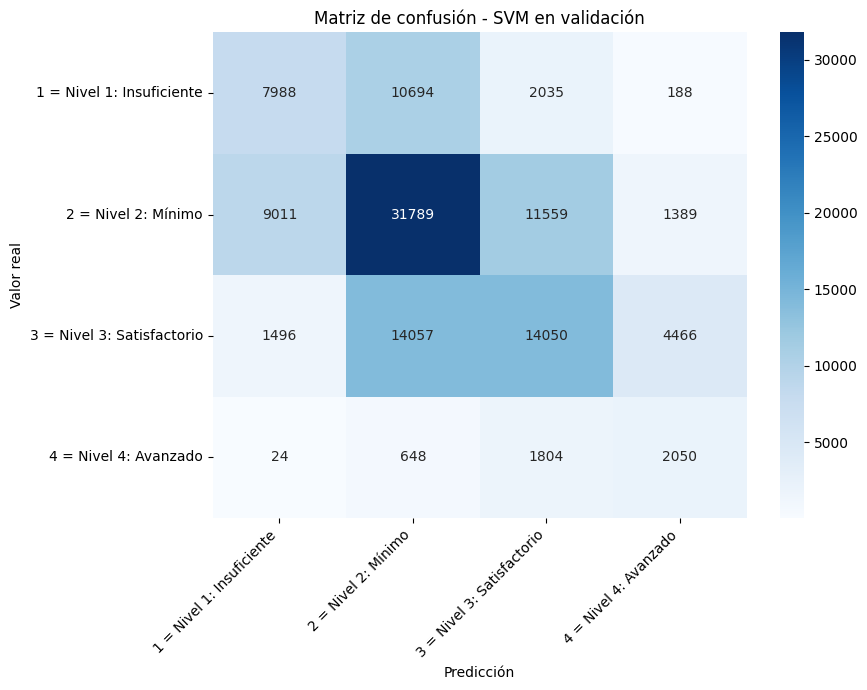

In [24]:
# ============================================================
# 15.1 Matriz de confusión en validación
# ============================================================

cm_val = confusion_matrix(
    y_val,
    y_pred_val_final,
    labels=TARGET_LABELS_CODIFICADOS
)

clases_nombres = [
    f"{codigo} = {TARGET_CODIGO_A_ETIQUETA[codigo]}"
    for codigo in TARGET_LABELS_CODIFICADOS
]

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_val,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clases_nombres,
    yticklabels=clases_nombres
)
plt.title("Matriz de confusión - SVM en validación")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 14. Evaluación final en test

In [25]:
# ============================================================
# 16. Reentrenamiento final con train + val y evaluación en test
# ============================================================

# Se clona el mejor pipeline y se reentrena con train + val completos.
# Test no participa en la selección de hiperparámetros ni en el ajuste de transformadores.
modelo_svm_final = clone(mejor_grid_svm.best_estimator_)
modelo_svm_final.fit(X_train_val, y_train_val)

y_pred_test = pd.Series(
    modelo_svm_final.predict(X_test),
    index=y_test.index,
    name="prediccion_test"
).astype(int)

metricas_test_svm = pd.DataFrame({
    "modelo_final": [mejor_nombre_svm],
    "dataset_evaluacion": ["test"],
    "accuracy": [accuracy_score(y_test, y_pred_test)],
    "f1_macro": [f1_score(y_test, y_pred_test, average="macro", zero_division=0)],
    "f1_weighted": [f1_score(y_test, y_pred_test, average="weighted", zero_division=0)],
    "n_train_val": [len(X_train_val)],
    "n_test": [len(X_test)]
})

display(metricas_test_svm)

print("Reporte de clasificación en TEST:")
print(classification_report(
    y_test,
    y_pred_test,
    labels=TARGET_LABELS_CODIFICADOS,
    target_names=[str(TARGET_CODIGO_A_ETIQUETA[c]) for c in TARGET_LABELS_CODIFICADOS],
    zero_division=0
))


,modelo_final,dataset_evaluacion,accuracy,f1_macro,f1_weighted,n_train_val,n_test
0,SVM_GridSearchCV_amplio,test,0.492773,0.436612,0.491747,452992,113249


Reporte de clasificación en TEST:
                        precision    recall  f1-score   support

 Nivel 1: Insuficiente       0.43      0.38      0.41     20905
       Nivel 2: Mínimo       0.55      0.59      0.57     53749
Nivel 3: Satisfactorio       0.47      0.41      0.44     34069
     Nivel 4: Avanzado       0.26      0.45      0.33      4526

              accuracy                           0.49    113249
             macro avg       0.43      0.46      0.44    113249
          weighted avg       0.50      0.49      0.49    113249



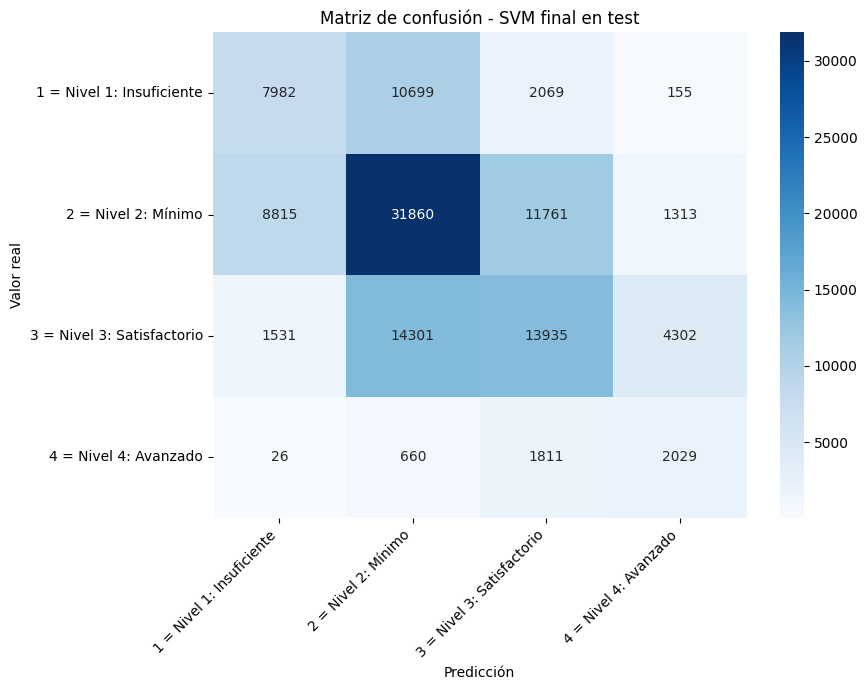

In [26]:
# ============================================================
# 16.1 Matriz de confusión final en test
# ============================================================

cm_test = confusion_matrix(
    y_test,
    y_pred_test,
    labels=TARGET_LABELS_CODIFICADOS
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clases_nombres,
    yticklabels=clases_nombres
)
plt.title("Matriz de confusión - SVM final en test")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 15. Guardado e inferencia

In [27]:
# ============================================================
# 17. Verificación de preprocesamiento y guardado de artefactos
# ============================================================

pipeline_preprocesamiento_final = Pipeline(steps=modelo_svm_final.steps[:-1])

# Estas transformaciones usan únicamente parámetros aprendidos durante fit(X_train_val, y_train_val).
X_train_val_preprocesado = pipeline_preprocesamiento_final.transform(X_train_val)
X_test_preprocesado = pipeline_preprocesamiento_final.transform(X_test)

print("X_train_val original:", X_train_val.shape)
print("X_train_val preprocesado:", X_train_val_preprocesado.shape)
print("X_test original:", X_test.shape)
print("X_test preprocesado:", X_test_preprocesado.shape)

assert X_train_val_preprocesado.shape[1] == X_test_preprocesado.shape[1]

MODEL_PATH = os.path.join(BASE_DIR, "modelo_svm_gridsearchcv_extendido_pipeline.joblib")
RESULTADOS_VAL_PATH = os.path.join(BASE_DIR, "resultados_svm_gridsearchcv_extendido_validacion.csv")
CV_RESULTS_AMPLIO_PATH = os.path.join(BASE_DIR, "cv_results_svm_gridsearchcv_amplio.csv")
CV_RESULTS_FINO_PATH = os.path.join(BASE_DIR, "cv_results_svm_gridsearchcv_fino.csv")
METRICAS_TEST_PATH = os.path.join(BASE_DIR, "metricas_test_svm_gridsearchcv_extendido.csv")
MAPEO_TARGET_PATH = os.path.join(BASE_DIR, "mapeo_target_svm_gridsearchcv_extendido.csv")

artefacto_svm = {
    "modelo": modelo_svm_final,
    "mejor_modelo_nombre": mejor_nombre_svm,
    "best_params": mejor_grid_svm.best_params_,
    "target_col": TARGET_COL,
    "target_label_encoder": target_label_encoder,
    "mapeo_target": mapeo_target,
    "target_labels_originales": TARGET_LABELS_ORIGINALES,
    "target_labels_codificados": TARGET_LABELS_CODIFICADOS,
    "target_codigo_a_etiqueta": TARGET_CODIGO_A_ETIQUETA,
    "target_etiqueta_a_codigo": TARGET_ETIQUETA_A_CODIGO,
    "columnas_entrenamiento": X_train_val.columns.tolist(),
    "metricas_validacion": resultados_svm_val,
    "metricas_test": metricas_test_svm,
    "columnas_eliminadas": columnas_existentes_a_eliminar,
    "columnas_sospechosas_leakage": columnas_sospechosas_leakage,
    "columnas_leakage_confirmadas": COLUMNAS_LEAKAGE_CONFIRMADAS,
    "ordinal_cols": ordinal_cols,
    "nominal_cols": nominal_cols,
    "numeric_cols": numeric_cols,
    "split_config": {
        "test_size": TEST_SIZE,
        "val_size": VAL_SIZE,
        "k_folds": K_FOLDS,
        "seed": SEED
    },
    "shape_X_train_val_preprocesado": X_train_val_preprocesado.shape,
    "shape_X_test_preprocesado": X_test_preprocesado.shape
}

joblib.dump(artefacto_svm, MODEL_PATH)
resultados_svm_val.to_csv(RESULTADOS_VAL_PATH, index=False, encoding="utf-8-sig")
cv_results_svm_amplio.to_csv(CV_RESULTS_AMPLIO_PATH, index=False, encoding="utf-8-sig")
if not cv_results_svm_fino.empty:
    cv_results_svm_fino.to_csv(CV_RESULTS_FINO_PATH, index=False, encoding="utf-8-sig")
metricas_test_svm.to_csv(METRICAS_TEST_PATH, index=False, encoding="utf-8-sig")
mapeo_target.to_csv(MAPEO_TARGET_PATH, index=False, encoding="utf-8-sig")

print("Artefactos guardados correctamente:")
print("Modelo:", MODEL_PATH)
print("Resultados validación:", RESULTADOS_VAL_PATH)
print("CV amplio:", CV_RESULTS_AMPLIO_PATH)
if not cv_results_svm_fino.empty:
    print("CV fino:", CV_RESULTS_FINO_PATH)
print("Métricas test:", METRICAS_TEST_PATH)
print("Mapeo target:", MAPEO_TARGET_PATH)


X_train_val original: (452992, 16)
X_train_val preprocesado: (452992, 38)
X_test original: (113249, 16)
X_test preprocesado: (113249, 38)
Artefactos guardados correctamente:
Modelo: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/modelo_svm_gridsearchcv_extendido_pipeline.joblib
Resultados validación: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/resultados_svm_gridsearchcv_extendido_validacion.csv
CV amplio: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/cv_results_svm_gridsearchcv_amplio.csv
CV fino: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/cv_results_svm_gridsearchcv_fino.csv
Métricas test: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/metricas_test_svm_gridsearchcv_extendido.csv
Mapeo target: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/mapeo_target_svm_gridsearchcv_extendido.cs

In [28]:
# ============================================================
# 18. Ejemplo de inferencia
# ============================================================

n_ejemplo = min(5, len(X_test))
nuevos_datos = X_test.head(n_ejemplo).copy()

predicciones_codificadas = pd.Series(
    modelo_svm_final.predict(nuevos_datos),
    index=nuevos_datos.index,
    name="prediccion_codificada"
).astype(int)

resultado_inferencia = nuevos_datos.copy()
resultado_inferencia["prediccion_codificada"] = predicciones_codificadas
resultado_inferencia["prediccion_etiqueta"] = decodificar_target(predicciones_codificadas)

display(resultado_inferencia)


,estu_tipodocumento,cole_bilingue,cole_calendario,cole_caracter,cole_genero,cole_jornada,cole_mcpio_ubicacion,cole_naturaleza,estu_genero,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_personashogar,fami_tienecomputador,fami_tieneinternet,prediccion_codificada,prediccion_etiqueta
455741,TI,N,A,TÉCNICO/ACADÉMICO,MIXTO,MAÑANA,CALI,OFICIAL,F,Cinco,Educación profesional incompleta,No sabe,Estrato 2,5 a 6,Si,Si,2,Nivel 2: Mínimo
535232,CC,N,A,ACADÉMICO,MIXTO,SABATINA,MEDELLÍN,NO OFICIAL,F,Dos,Primaria incompleta,Primaria incompleta,Estrato 2,5 a 6,No,No,1,Nivel 1: Insuficiente
55133,TI,NaN,A,ACADÉMICO,MIXTO,COMPLETA,SOACHA,NO OFICIAL,M,Tres,No sabe,No sabe,Estrato 3,3 a 4,Si,Si,3,Nivel 3: Satisfactorio
11946,TI,NaN,B,ACADÉMICO,MIXTO,MAÑANA,CALI,NO OFICIAL,M,Tres,Técnica o tecnológica incompleta,Educación profesional completa,Estrato 4,3 a 4,Si,Si,4,Nivel 4: Avanzado
414565,TI,N,A,TÉCNICO/ACADÉMICO,MIXTO,UNICA,BARRANCABERMEJA,OFICIAL,M,Uno,No sabe,No sabe,Estrato 2,1 a 2,No,Si,2,Nivel 2: Mínimo


## Conclusión metodológica

Esta iteración profundiza únicamente en SVM, usando una búsqueda más amplia y una búsqueda fina posterior. El conjunto `test` permanece aislado hasta el final; por tanto, las métricas finales no intervienen en la selección del modelo ni en el ajuste de hiperparámetros.